
# KELT-20 Gaia astrometry simulation

This notebook simulates Gaia-like astrometric data for a low-mass and high-mass solution to KELT-20





In [1]:
import matplotlib 
matplotlib.rc('xtick', labelsize=18) 
matplotlib.rc('ytick', labelsize=18) 
matplotlib.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
matplotlib.rc('text', usetex=True)

In [47]:
# %% [markdown]
# Kepler helpers (for fitting) + multi-planet astrometric simulator using jaxoplanet

# ----------------- Orbit / astrometry helpers for FITTING ONLY -----------------
def kepler_E(M, e, tol=1e-12, maxiter=50):
    """Solve Kepler's equation M = E - e sin E for E."""
    E = M + (e*np.sin(M)) / (1 - np.sin(M + e) + np.sin(M))  # good initial guess
    for _ in range(maxiter):
        dE = -(E - e*np.sin(E) - M) / (1 - e*np.cos(E))
        E += dE
        if np.all(np.abs(dE) < tol):
            break
    return E

def orbital_basis(t, P, e, M0):
    """
    Return X,Y basis functions for a Keplerian ellipse at times t (years).
    X,Y are the standard elliptical coordinates in the orbital plane.
    """
    n = 2*np.pi / P
    M = n*t + M0
    E = kepler_E(M % (2*np.pi), e)
    X = np.cos(E) - e
    Y = np.sqrt(1 - e**2) * np.sin(E)
    return X, Y

def a_star_mas(P_yr, Mp_Mjup, Mstar_Msun=1.0, dist_pc=20.0):
    """Approximate astrometric semi-major axis of the star (mas) for sanity checks."""
    Mp_over_Ms = Mp_Mjup * MJUP_TO_MSUN / Mstar_Msun
    a_planet_AU = (P_yr**2 * Mstar_Msun)**(1/3)
    alpha_arcsec = Mp_over_Ms * a_planet_AU / dist_pc
    return alpha_arcsec * 1000.0  # mas

# --- jaxoplanet-backed MULTI-planet simulator (R_sun -> AU -> arcsec -> mas) ---
import jax
import jax.numpy as jnp
from jaxoplanet.orbits.keplerian import Central, System

def simulate_gaia_astrometry_multi(
    t, psi,
    planets,            # list of dicts with keys like {"a":au,"e":...,"i":rad,"Omega":rad,"omega":rad,"M0":rad,"Mp_sun":Msun} or Mp (M_Jup)
    Mstar, dist_pc,
    x0_true=0.0, y0_true=0.0,
    sigma_AL=0.054, seed=45
):
    """
    Simulate Gaia-like astrometry for a multi-companion system.

    Notes
    -----
    - Internally we need an orbital period to convert mean anomaly (M0) into a time of periastron.
      If each planet dict provides:
        * P (years), it will be used.
      Otherwise we compute the period from Kepler's third law using (a, Mstar, Mp_sun).

    - Mass units:
        * If 'Mp_sun' is provided, it is interpreted as M_sun.
        * Else if 'Mp' is provided, it is interpreted as M_Jup (backwards compatible).

    Returns a dict containing true sky offsets (x_true,y_true), along-scan truth/obs (al_true,al_obs),
    and (optionally) noisy x_obs,y_obs can be constructed with make_ra_dec_observations().
    """
    import math
    t_days = jnp.asarray(t * 365.25)

    star = Central(mass=jnp.asarray(Mstar), radius=jnp.asarray(1.0))
    sys  = System(star)

    for p in planets:
        a_au = float(p["a"])

        # Mass handling
        if "Mp_sun" in p:
            mp_sun = float(p["Mp_sun"])
        else:
            mp_sun = float(p.get("Mp", 0.0)) * MJUP_TO_MSUN

        # Period handling
        if "P" in p and p["P"] is not None:
            P_year = float(p["P"])
        else:
            # Kepler's third law in (AU, Msun, years)
            P_year = math.sqrt(a_au**3 / (float(Mstar) + mp_sun))
            
        print(P_year)

        P_days = P_year * 365.25
        n = 2.0 * math.pi / P_days  # rad/day

        # Convert mean anomaly at t=0 into time-of-periastron (days, relative to t=0)
        t_peri_days = - float(p["M0"]) / n

        sys = sys.add_body(
            period=jnp.asarray(P_days),
            eccentricity=jnp.asarray(float(p["e"])),
            inclination=jnp.asarray(float(p["i"])),
            omega_peri=jnp.asarray(float(p["omega"])),
            asc_node=jnp.asarray(float(p["Omega"])),
            time_peri=jnp.asarray(t_peri_days),
            mass=jnp.asarray(mp_sun),
        )

    bodies = sys.bodies

    # Sum the star's reflex due to each body (each central_position is in R_sun)
    x_sum = 0.0
    y_sum = 0.0
    for b in bodies:
        x_rsun, y_rsun, _ = b.central_position(t_days)
        x_sum = x_sum + x_rsun
        y_sum = y_sum + y_rsun

    # Convert R_sun -> AU -> arcsec (AU/d_pc) -> mas
    x_true = np.asarray(x_sum) * RSUN_TO_AU * (1000.0 / dist_pc) + x0_true
    y_true = np.asarray(y_sum) * RSUN_TO_AU * (1000.0 / dist_pc) + y0_true

    # Project to Gaia along-scan and add noise
    rng = np.random.default_rng(seed)
    al_true = x_true*np.cos(psi) + y_true*np.sin(psi)
    al_obs  = al_true + rng.normal(0, sigma_AL, size=len(al_true))

    return dict(
        t=t, psi=psi,
        x_true=x_true, y_true=y_true,
        al_obs=al_obs, al_true=al_true,
        sigma=sigma_AL,
        truth={"planets": planets},
    )


def make_ra_dec_observations(data):
    """
    Construct x_obs, y_obs that are perfectly consistent with the existing
    along-scan observations (al_obs) and the true AL model (al_true),
    and compute per-epoch RA/Dec uncertainties projected from AL sigma.

    This function REQUIRES data["al_obs"] and data["al_true"].
    It will raise a KeyError if they are missing.

    Notes
    -----
    Ensures that:
        x_obs*cos(psi) + y_obs*sin(psi) == al_obs
    exactly for every epoch.
    """

    # --- Require AL data ---
    if "al_obs" not in data or "al_true" not in data:
        raise KeyError(
            "make_ra_dec_observations requires data['al_obs'] and data['al_true']. "
            "These must be produced by simulate_gaia_astrometry_multi."
        )

    # --- Build x_obs, y_obs only if not already present ---
    if ("x_obs" not in data) or ("y_obs" not in data):
        eps = data["al_obs"] - data["al_true"]    # actual AL noise
        c, s = np.cos(data["psi"]), np.sin(data["psi"])

        x_obs = data["x_true"] + eps * c
        y_obs = data["y_true"] + eps * s

        data = dict(data, x_obs=x_obs, y_obs=y_obs)

    # --- Marginal RA/Dec uncertainties (for plotting only) ---
    sigma_ra  = data["sigma"] * np.abs(np.cos(data["psi"]))
    sigma_dec = data["sigma"] * np.abs(np.sin(data["psi"]))

    return data, sigma_ra, sigma_dec






In [54]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------


def build_scan_times(duration_yr, ra_deg=20.0, dec_deg=-45.0):
    """
    Build Gaia scan times and along-scan angles over a given duration.

    Returns:
        t       : times relative to mid-baseline (for numerics)
        psi     : along-scan angles [rad]
        times_year : absolute times in years (this is what we want on the x-axis)
        T_span  : actual span in years
    """
    tstart = gaiascanlaw.tstart
    tend   = tstart + duration_yr
    times_year, scan_angles = gaiascanlaw.scanlaw(
        ra_deg, dec_deg, tstart=tstart, tend=tend
    )
    times_year = np.asarray(times_year)
    psi        = np.asarray(scan_angles)  # radians

    # Re-center time for numerical stability
    t     = times_year - tstart   # years relative to mid-baseline

    T_span = times_year.max() - times_year.min()  # actual span
    print(t)
    print(times_year)
    print(T_span)
    print('')
    return t, psi, times_year, T_span


def make_output_paths(duration_yr):
    """
    Decide folder and filename tags based on baseline & mutual inclination.
    Returns (folder_base, baseline_tag, geom_tag).
    """
    # Baseline tag
    if duration_yr <= 6.0:
        baseline_tag = "dr4"
        base_folder  = "gaia_dr4"
    else:
        baseline_tag = "dr5"
        base_folder  = "gaia_dr5"


    folder_base = "figures"
    return folder_base, baseline_tag


# ---------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------


# ---------------------------------------------------------------------
# Plotting (single-companion / "one solution" mode)
# ---------------------------------------------------------------------

def plot_and_save_figures(
    data,
    sigma_ra,
    sigma_dec,
    sigma_arr,
    folder_base,
    baseline_tag,
    solution_tag,
    color,
    t_plot,
    fig_suptitle,
):
    """
    Make three figures for a single-companion solution and save them.

    Figures:
      1) Sky-plane offsets (ΔRA*, ΔDec)
      2) ΔRA* and ΔDec versus time
      3) Along-scan (AL) versus time + residuals

    Parameters
    ----------
    t_plot : array-like
        Times in years (absolute mission-time axis from build_scan_times()).
    """
    # Common styles
    err_kw = dict(fmt="none", ecolor="black", elinewidth=1, alpha=0.36, capsize=0)
    pt_kw  = dict(marker="o", ls="none", ms=3, color="black", alpha=0.9)

    # Convenience aliases
    x_obs   = data["x_obs"]
    y_obs   = data["y_obs"]
    x_true  = data["x_true"]
    y_true  = data["y_true"]
    al_obs  = data["al_obs"]
    al_true = data["al_true"]
    psi_arr = data["psi"]

    outdir = os.path.join(folder_base, baseline_tag, solution_tag)
    os.makedirs(outdir, exist_ok=True)

    # -----------------------------------------------------------------
    # Plot 1: sky-plane (ΔRA*, ΔDec)
    # -----------------------------------------------------------------
    plt.figure(figsize=(9, 9))

    for i in range(len(x_obs)):
        dx_err = data["sigma"] * np.cos(psi_arr[i])
        dy_err = data["sigma"] * np.sin(psi_arr[i])
        plt.plot(
            [x_obs[i] - dx_err, x_obs[i] + dx_err],
            [y_obs[i] - dy_err, y_obs[i] + dy_err],
            color="black", alpha=0.25, lw=1,
        )

    plt.plot(x_obs, y_obs, **pt_kw, label=r"Mock \textit{Gaia}-like data")
    plt.plot(x_true, y_true, color=color, lw=3, alpha=0.9, label="Truth model")

    plt.xlabel(r"$\Delta\alpha^*\;[\mathrm{mas}]$", fontsize=22)
    plt.ylabel(r"$\Delta\delta\;[\mathrm{mas}]$", fontsize=22)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.legend(loc="best", fontsize=16)
    plt.title(fig_suptitle, fontsize=18)
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, "sky_plane.png"), dpi=200)
    plt.close()

    # -----------------------------------------------------------------
    # Plot 2: RA/Dec vs time
    # -----------------------------------------------------------------
    plt.figure(figsize=(11, 6))
    plt.errorbar(t_plot, x_obs, yerr=sigma_ra, **err_kw)
    plt.plot(t_plot, x_obs, **pt_kw)
    plt.plot(t_plot, x_true, color=color, lw=3, alpha=0.9, label=r"$\Delta\alpha^*$ truth")
    plt.xlabel("Time [yr]", fontsize=22)
    plt.ylabel(r"$\Delta\alpha^*\;[\mathrm{mas}]$", fontsize=22)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.legend(fontsize=16, loc="best")
    plt.title(fig_suptitle, fontsize=18)
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, "ra_vs_time.png"), dpi=200)
    plt.close()

    plt.figure(figsize=(11, 6))
    plt.errorbar(t_plot, y_obs, yerr=sigma_dec, **err_kw)
    plt.plot(t_plot, y_obs, **pt_kw)
    plt.plot(t_plot, y_true, color=color, lw=3, alpha=0.9, label=r"$\Delta\delta$ truth")
    plt.xlabel("Time [yr]", fontsize=22)
    plt.ylabel(r"$\Delta\delta\;[\mathrm{mas}]$", fontsize=22)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.legend(fontsize=16, loc="best")
    plt.title(fig_suptitle, fontsize=18)
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, "dec_vs_time.png"), dpi=200)
    plt.close()

    # -----------------------------------------------------------------
    # Plot 3: along-scan and residuals
    # -----------------------------------------------------------------
    residuals = al_obs - al_true

    plt.figure(figsize=(11, 6))
    plt.errorbar(t_plot, al_obs, yerr=sigma_arr, **err_kw)
    plt.plot(t_plot, al_obs, **pt_kw)
    plt.plot(t_plot, al_true, color=color, lw=3, alpha=0.9, label="Truth AL")
    plt.xlabel("Time [yr]", fontsize=22)
    plt.ylabel(r"$\Delta\mathrm{AL}\;[\mathrm{mas}]$", fontsize=22)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.legend(fontsize=16, loc="best")
    plt.title(fig_suptitle, fontsize=18)
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, "al_vs_time.png"), dpi=200)
    plt.close()

    plt.figure(figsize=(11, 4))
    plt.errorbar(t_plot, residuals, yerr=sigma_arr, **err_kw)
    plt.plot(t_plot, residuals, **pt_kw)
    plt.axhline(0.0, lw=2, alpha=0.6)
    plt.xlabel("Time [yr]", fontsize=22)
    plt.ylabel("AL resid [mas]", fontsize=22)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.title(fig_suptitle + " (residuals)", fontsize=18)
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, "al_residuals.png"), dpi=200)
    plt.close()


# ---------------------------------------------------------------------
# Main runner (single solution)
# ---------------------------------------------------------------------

def run_case(
    duration_yr,
    solution_params,
    solution_tag,
    color,
    fig_suptitle,
    *,
    ra_deg,
    dec_deg,
    Mstar,
    dist_pc,
    sigma_AL,
    seed=45,
    save_data=True,
):
    """
    Simulate a single-companion astrometric orbit for a given Gaia baseline.

    solution_params must contain:
      t0, m2, a2, e2, Omega2, omega2, i2, M2_0
    where:
      t0 is BJD-2457000 (used only for labeling / bookkeeping here)
      m2 is M_sun
      a2 is AU
      angles are radians
      M2_0 is mean anomaly at t0 in radians

    Time convention here:
      We treat the simulator's t=0 (mid-baseline) as coincident with t0, so M0=M2_0.
      If you later want to tie the phase to an absolute Gaia epoch, you can shift M0 by n*Δt.

    Returns
    -------
    data, times_year, sigma_ra, sigma_dec
    """
    # 1) Gaia sampling for the target sky position
    t, psi, times_year, T_span = build_scan_times(duration_yr, ra_deg=ra_deg, dec_deg=dec_deg)

    # 2) Build a single-companion model
    t0, m2, a2, e2, Omega2, omega2, i2, M2_0 = [float(x) for x in solution_params]

    planets = [dict(
        a=a2,
        e=e2,
        i=i2,
        Omega=Omega2,
        omega=omega2,
        M0=M2_0,
        Mp_sun=m2,
    )]

    data = simulate_gaia_astrometry_multi(
        t, psi,
        planets=planets,
        Mstar=Mstar,
        dist_pc=dist_pc,
        sigma_AL=sigma_AL,
        seed=seed,
    )
    data, sigma_ra, sigma_dec = make_ra_dec_observations(data)

    # sigma array for plotting
    sigma_val = data["sigma"]
    if np.isscalar(sigma_val):
        sigma_arr = np.full_like(data["al_obs"], sigma_val, dtype=float)
    else:
        sigma_arr = np.asarray(sigma_val, dtype=float)

    # 3) Output paths
    folder_base, baseline_tag = make_output_paths(duration_yr) 

    # 4) Plots
    plot_and_save_figures(
        data=data,
        sigma_ra=sigma_ra,
        sigma_dec=sigma_dec,
        sigma_arr=sigma_arr,
        folder_base=folder_base,
        baseline_tag=baseline_tag,
        solution_tag=solution_tag,
        color=color,
        t_plot=times_year,
        fig_suptitle=fig_suptitle,
    )

    # 5) Save mock "DRx-like" data products
    if save_data:
        outdir = os.path.join(folder_base, baseline_tag, solution_tag)
        os.makedirs(outdir, exist_ok=True)

        np.savez(
            os.path.join(outdir, "mock_gaia_astrometry.npz"),
            times_year=times_year,
            t_rel_year=data["t"],
            psi_rad=data["psi"],
            x_obs_mas=data["x_obs"],
            y_obs_mas=data["y_obs"],
            x_true_mas=data["x_true"],
            y_true_mas=data["y_true"],
            al_obs_mas=data["al_obs"],
            al_true_mas=data["al_true"],
            sigma_al_mas=np.asarray(sigma_arr),
            sigma_ra_mas=np.asarray(sigma_ra),
            sigma_dec_mas=np.asarray(sigma_dec),
            t0_bjd_minus_2457000=t0,
            Mstar_msun=Mstar,
            dist_pc=dist_pc,
            m2_msun=m2,
            a2_au=a2,
            e2=e2,
            Omega2=Omega2,
            omega2=omega2,
            i2=i2,
            M2_0=M2_0,
        )

    return data, times_year, sigma_ra, sigma_dec



In [55]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt

# ---- Gaia scan law ----
try:
    import gaiascanlaw
except ImportError as e:
    raise ImportError("Please `pip install gaiascanlaw` before running this notebook.") from e

# ---- jaxoplanet orbit backend (used by simulate_gaia_astrometry_multi) ----
try:
    import jax.numpy as jnp
    from jaxoplanet.orbits.keplerian import Central, System
except ImportError as e:
    raise ImportError(
        "This notebook uses jaxoplanet for the astrometric reflex simulation. "
        "Please `pip install jax jaxlib jaxoplanet`."
    ) from e

# ----------------- Constants -----------------
MJUP_TO_MSUN = 0.0009543     # 1 M_Jup in M_sun
RSUN_TO_AU   = 0.00465047    # 1 R_sun in AU

# ----------------- KELT-20 inputs -----------------
MSTAR   = 1.89       # host mass [M_sun]
DIST_PC = 136.98     # distance [pc] from 1/parallax, parallax=7.3001 mas

# ICRS (J2000) from Simbad:
#   RA  = 19 38 38.7352230144
#   Dec = +31 13 09.217127532
def hms_to_deg(h, m, s):
    return 15.0 * (h + m/60.0 + s/3600.0)

def dms_to_deg(sign, d, m, s):
    return sign * (abs(d) + m/60.0 + s/3600.0)

KELT20_RA_DEG  = hms_to_deg(19, 38, 38.7352230144)
KELT20_DEC_DEG = dms_to_deg(+1, 31, 13, 9.217127532)

# Along-scan single-epoch uncertainty [mas]
# (set this to whatever is appropriate for your magnitude / gating assumptions)
sigma_AL = 0.054

# ----------------- Two companion solutions (user-provided) -----------------
sol_lowmass = np.array([
    2.42429770e+03,  # t0 (BJD-2457000)
    3.83356573e-02,  # m2 [M_sun]
    6.25608017e+00,  # a2 [AU]
    7.24328243e-01,  # e2
    8.24920550e-01,  # Omega2 [rad]
    2.94193325e+00,  # omega2 [rad]
    2.71177073e+00,  # i2 [rad]
    5.04875733e+00,  # M2_0 [rad]
])

sol_highmass = np.array([
    2.42429770e+03,  # t0 (BJD-2457000)
    2.41663303e-01,  # m2 [M_sun]
    1.00892852e+01,  # a2 [AU]
    8.32161012e-01,  # e2
    9.28886744e-01,  # Omega2 [rad]
    3.41139381e+00,  # omega2 [rad]
    1.78208235e+00,  # i2 [rad]
    4.04941486e+00,  # M2_0 [rad]
])

solutions = [
    ("low-mass solution", sol_lowmass, "tab:blue"),
    ("high-mass solution", sol_highmass, "tab:orange"),
]

# ----------------- Gaia baselines to mock -----------------
# This notebook's helper 'make_output_paths' labels <=6 yr as DR4 and >6 yr as DR5.
baselines = [
    ("Gaia DR4-like", 5.5),
    ("Gaia DR5-like", 10.5),
]

# ----------------- Run and save -----------------
results = {}

for baseline_name, duration_yr in baselines:
    for sol_tag, sol_params, color in solutions:
        fig_title = f"KELT-20 mock {baseline_name}  |  {sol_tag}"
        key = (baseline_name, sol_tag)

        data, times_year, sigma_ra, sigma_dec = run_case(
            duration_yr=duration_yr,
            solution_params=sol_params,
            solution_tag=sol_tag,
            color=color,
            fig_suptitle=fig_title,
            ra_deg=KELT20_RA_DEG,
            dec_deg=KELT20_DEC_DEG,
            Mstar=MSTAR,
            dist_pc=DIST_PC,
            sigma_AL=sigma_AL,
            seed=45,
            save_data=True,
        )
        results[key] = dict(data=data, times_year=times_year, sigma_ra=sigma_ra, sigma_dec=sigma_dec)

print("Done. Outputs saved under ./figures/gaia_dr4/ and ./figures/gaia_dr5/")


[0.16883593 0.26705078 0.26725338 0.35735138 0.42374602 0.42394863
 0.55923096 0.55943359 0.55991588 0.62105035 0.62153266 0.62173529
 0.72142343 0.87488243 0.99772714 0.99792976 1.02648731 1.02668993
 1.14747707 1.20448302 1.20496528 1.39805924 1.39854151 1.45741828
 1.4576209  1.592905   1.59310763 1.66272544 1.66292807 1.75255781
 1.85562371 1.85582634 1.90443141 1.90491372 2.0293181  2.02952072
 2.06013116 2.06033378 2.24203417 2.44110719 2.4413098  2.44179208
 2.49383017 2.49403279 2.62556893 2.62605124 2.70270165 2.70290429
 2.78364491 2.89305395 2.93413353 2.93461584 3.0592158  3.09530101
 3.09550362 3.20673736 3.27946422 3.35999621 3.36019883 3.48383562
 3.48403824 3.48452053 3.48472315 3.5345074  3.53471002 3.65787308
 3.7418332  3.74203583 3.81437034 3.81457298 3.92923625 3.92943888
 3.96415725 3.96435987 4.08855409 4.0887567  4.13120113 4.1316834
 4.31770422 4.31790683 4.39161261 4.39181522 4.52318911 4.52367142
 4.52387404 4.52435633 4.57776419 4.57796681 4.57844912 4.57865

[ 0.16883593  0.26705078  0.26725338  0.35735138  0.42374602  0.42394863
  0.55923096  0.55943359  0.55991588  0.62105035  0.62153266  0.62173529
  0.72142343  0.87488243  0.99772714  0.99792976  1.02648731  1.02668993
  1.14747707  1.20448302  1.20496528  1.39805924  1.39854151  1.45741828
  1.4576209   1.592905    1.59310763  1.66272544  1.66292807  1.75255781
  1.85562371  1.85582634  1.90443141  1.90491372  2.0293181   2.02952072
  2.06013116  2.06033378  2.24203417  2.44110719  2.4413098   2.44179208
  2.49383017  2.49403279  2.62556893  2.62605124  2.70270165  2.70290429
  2.78364491  2.89305395  2.93413353  2.93461584  3.0592158   3.09530101
  3.09550362  3.20673736  3.27946422  3.35999621  3.36019883  3.48383562
  3.48403824  3.48452053  3.48472315  3.5345074   3.53471002  3.65787308
  3.7418332   3.74203583  3.81437034  3.81457298  3.92923625  3.92943888
  3.96415725  3.96435987  4.08855409  4.0887567   4.13120113  4.1316834
  4.31770422  4.31790683  4.39161261  4.39181522  4.

In [56]:
import numpy as np
import matplotlib.pyplot as plt

def plot_two_solutions_skyplane_side_by_side(
    results,
    baseline_name,
    solA_tag,
    solB_tag,
    colorA,
    colorB,
    suptitle=None,
    same_limits=False,
):
    """
    Side-by-side sky-plane comparison using the *original* sky-plane plotting style.

    Expects:
      results[(baseline_name, sol_tag)]["data"] contains:
        x_obs, y_obs, x_true, y_true, psi, sigma, t
    """

    dataA = results[(baseline_name, solA_tag)]["data"]
    dataB = results[(baseline_name, solB_tag)]["data"]

    def _panel(ax, data, model_color, model_label):
        x_obs = np.asarray(data["x_obs"])
        y_obs = np.asarray(data["y_obs"])
        x_true = np.asarray(data["x_true"])
        y_true = np.asarray(data["y_true"])
        psi = np.asarray(data["psi"])
        sigma_AL = np.asarray(data["sigma"])

        # --- Error bars as AL-projected line segments (same as original) ---
        for i in range(len(data["t"])):
            dx_err = sigma_AL * np.cos(psi[i])
            dy_err = sigma_AL * np.sin(psi[i])
            ax.plot(
                [x_obs[i] - dx_err, x_obs[i] + dx_err],
                [y_obs[i] - dy_err, y_obs[i] + dy_err],
                color="black", alpha=0.25, lw=1
            )

        # --- Observations (same marker/style as original) ---
        ax.plot(
            x_obs, y_obs, "o",
            ms=3, alpha=0.9, color="black",
            label=r"\textit{Gaia}-like data"
        )

        # --- True model track (same thickness/style as original) ---
        ax.plot(
            x_true, y_true,
            color=model_color, ls="-", lw=3, alpha=0.9, zorder=-100,
            label=model_label
        )

        # --- Labels / legend / aspect / grid (match original) ---
        ax.set_xlabel(r"$\Delta\alpha\,\cos\,\delta$ [mas]", fontsize=23)
        ax.set_ylabel(r"$\Delta\,\delta$ [mas]", fontsize=23)
        ax.legend(fontsize=23, loc=2)
        ax.set_aspect("equal", adjustable="datalim")
        ax.grid(alpha=0.3)

    # Figure size: two 9x9 panels side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(18, 9))

    _panel(axes[0], dataA, colorA, f"{solA_tag} model")
    _panel(axes[1], dataB, colorB, f"{solB_tag} model")

    if suptitle is None:
        suptitle = f"KELT-20 sky-plane comparison ({baseline_name})"
    fig.suptitle(suptitle, fontsize=22)

    # Optional: enforce same x/y limits across both panels for direct visual comparison
    if same_limits:
        xs = np.concatenate([dataA["x_obs"], dataA["x_true"], dataB["x_obs"], dataB["x_true"]])
        ys = np.concatenate([dataA["y_obs"], dataA["y_true"], dataB["y_obs"], dataB["y_true"]])
        xpad = 0.05 * (xs.max() - xs.min() + 1e-12)
        ypad = 0.05 * (ys.max() - ys.min() + 1e-12)
        xlim = (xs.min() - xpad, xs.max() + xpad)
        ylim = (ys.min() - ypad, ys.max() + ypad)
        for ax in axes:
            ax.set_xlim(*xlim)
            ax.set_ylim(*ylim)

    plt.tight_layout()
    plt.show()
    return fig, axes

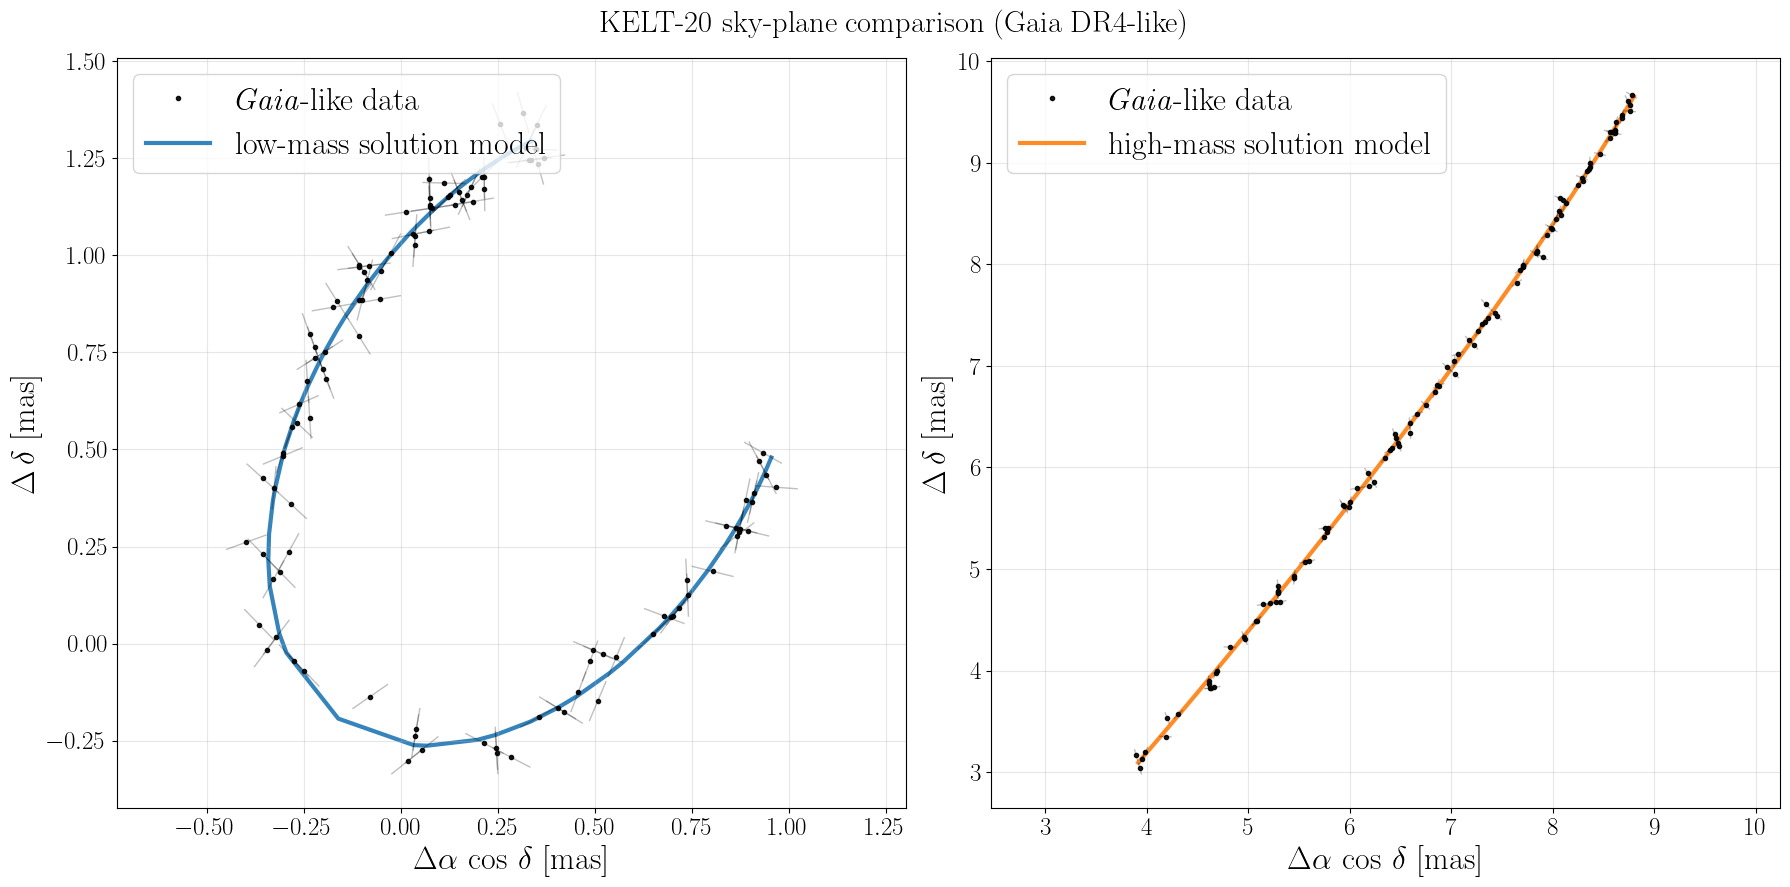

(<Figure size 1800x900 with 2 Axes>,
 array([<Axes: xlabel='$\\Delta\\alpha\\,\\cos\\,\\delta$ [mas]', ylabel='$\\Delta\\,\\delta$ [mas]'>,
        <Axes: xlabel='$\\Delta\\alpha\\,\\cos\\,\\delta$ [mas]', ylabel='$\\Delta\\,\\delta$ [mas]'>],
       dtype=object))

In [57]:
color_map = {sol_tag: color for sol_tag, sol_params, color in solutions}

plot_two_solutions_skyplane_side_by_side(
    results,
    baseline_name="Gaia DR4-like",
    solA_tag="low-mass solution",
    solB_tag="high-mass solution",
    colorA=color_map["low-mass solution"],
    colorB=color_map["high-mass solution"],
    same_limits=False,
)


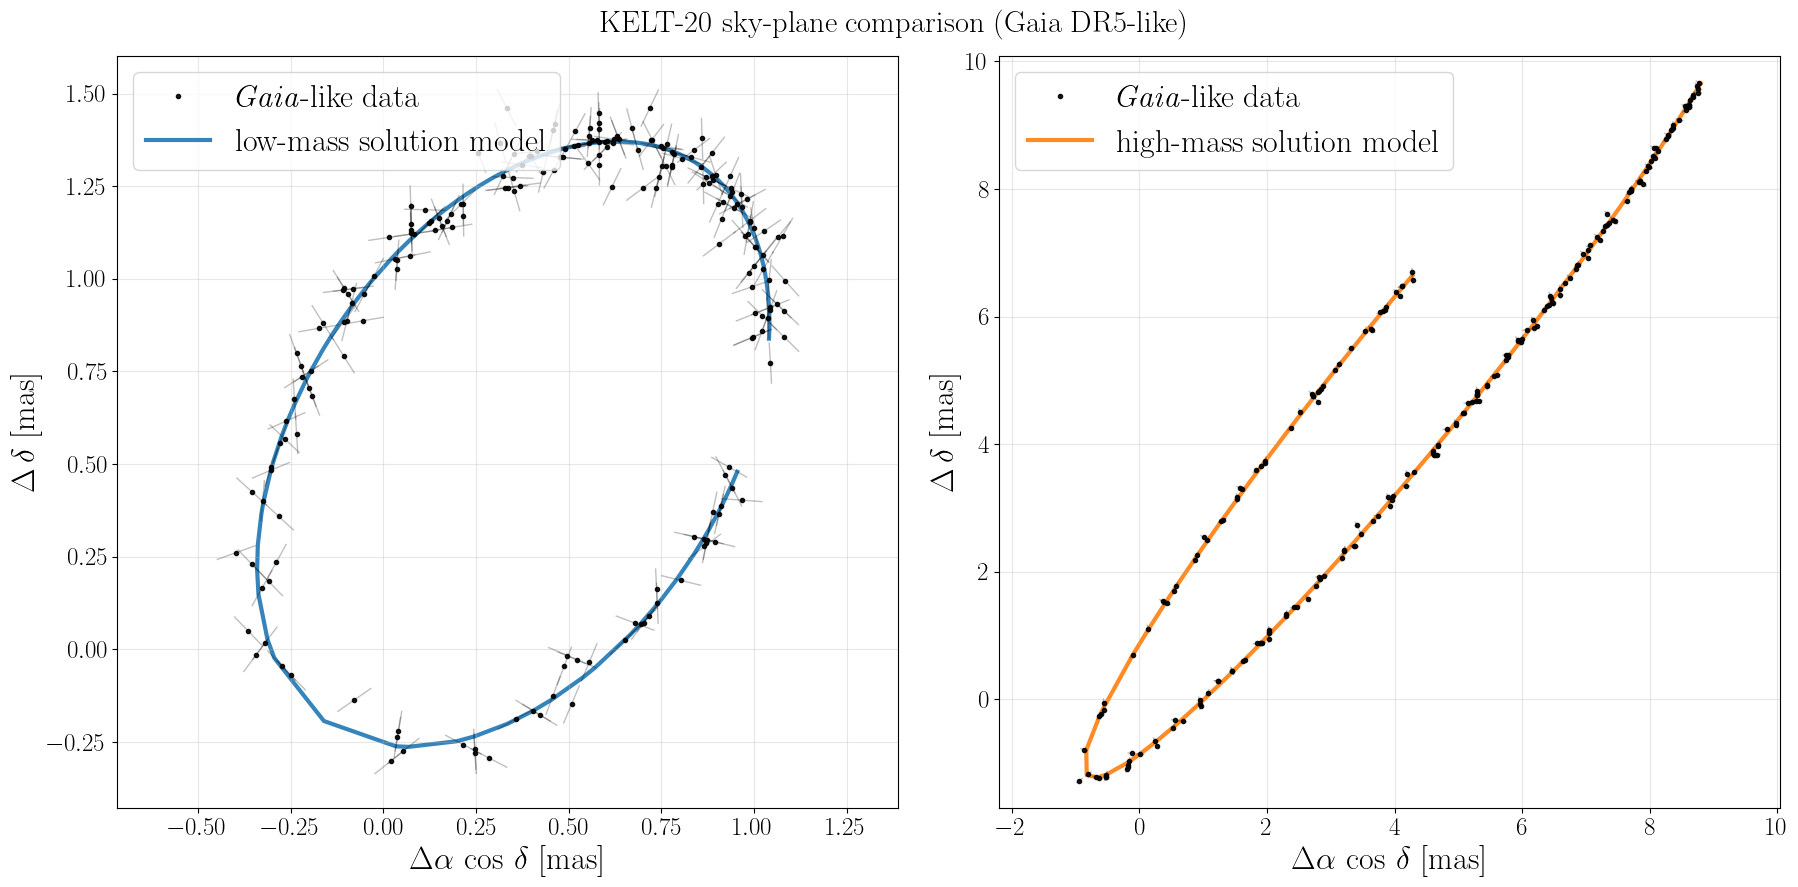

(<Figure size 1800x900 with 2 Axes>,
 array([<Axes: xlabel='$\\Delta\\alpha\\,\\cos\\,\\delta$ [mas]', ylabel='$\\Delta\\,\\delta$ [mas]'>,
        <Axes: xlabel='$\\Delta\\alpha\\,\\cos\\,\\delta$ [mas]', ylabel='$\\Delta\\,\\delta$ [mas]'>],
       dtype=object))

In [58]:
color_map = {sol_tag: color for sol_tag, sol_params, color in solutions}

plot_two_solutions_skyplane_side_by_side(
    results,
    baseline_name="Gaia DR5-like",
    solA_tag="low-mass solution",
    solB_tag="high-mass solution",
    colorA=color_map["low-mass solution"],
    colorB=color_map["high-mass solution"],
    same_limits=False,
)

